Final mean reconstruction error, 1.2161095244661334e-05


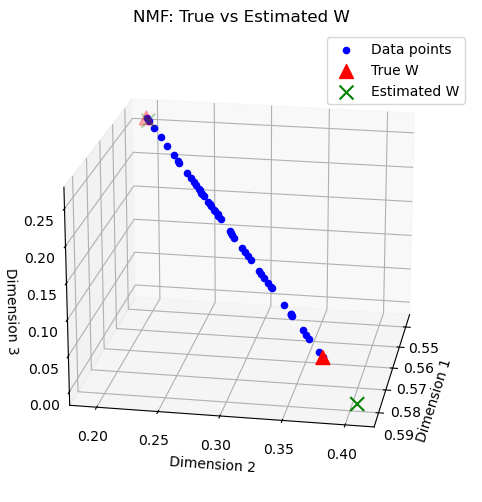

In [23]:
from cProfile import label
import numpy as np
import tensorly as tl
from tensorly.decomposition import non_negative_parafac_hals
from matplotlib import pyplot as plt

# Dimensions
n1, n2 = [3,50]
rank = 2

# Seed
rng = np.random.default_rng(5)

# Generating a dummy nonnegative matrix with exact NMF
W_true = rng.random((n1, rank))
H_true = rng.random((n2, rank))
M = W_true@H_true.T

# Computing NMF
out = non_negative_parafac_hals(M, rank, init="svd")
We = out[1][0]
He = out[1][1]
Me = We@He.T

# Computing final error
print(f"Final mean reconstruction error, {np.linalg.norm(M-Me)/n1/n2}")

# Plotting the 3d data points, true W positions as triangles and estimated W positions
# a. normalization of data, data_e and W
We = We / np.sum(We, axis=0)
W_true = W_true / np.sum(W_true, axis=0)
M = M / np.sum(M, axis=0)
Me = Me / np.sum(Me, axis=0)

# b. 3d plotting
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d', elev=20, azim=10)
# 3d data
for i in range(n2):
    ax.scatter(M[0,i], M[1,i], M[2,i], c='blue', label='Data points' if i==0 else "")
# increase markersize for better visibility
ax.scatter(W_true[0,:], W_true[1,:], W_true[2,:], s=100, c='red', marker='^', label='True W')
ax.scatter(We[0,:], We[1,:], We[2,:], s=100, c='green', marker='x', label='Estimated W')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
plt.title('NMF: True vs Estimated W')
plt.legend()
plt.grid()


Final mean reconstruction error with SNPA, 1.9767080278227526e-05


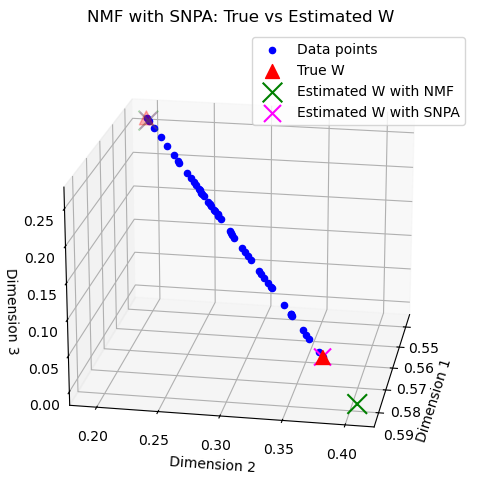

In [26]:
from tensorly_hdr.sep_nmf import snpa

_, We_snpa, He_snpa = snpa(Me, rank)
He_snpa = He_snpa.T
Me_snpa = We_snpa@He_snpa.T
print(f"Final mean reconstruction error with SNPA, {np.linalg.norm(M-Me_snpa)/n1/n2}")

# Plotting the 3d data points, true W positions as triangles and estimated W positions with SNPA
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d', elev=20, azim=10)
# 3d data
for i in range(n2):
    ax.scatter(M[0,i], M[1,i], M[2,i], c='blue', label='Data points' if i==0 else "")
# increase markersize for better visibility
ax.scatter(W_true[0,:], W_true[1,:], W_true[2,:], s=100, c='red', marker='^', label='True W')
ax.scatter(We[0,:], We[1,:], We[2,:], s=200, c='green', marker='x', label='Estimated W with NMF')
ax.scatter(We_snpa[0,:], We_snpa[1,:], We_snpa[2,:], s=150, c='magenta', marker='x', label='Estimated W with SNPA')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
plt.title('NMF with SNPA: True vs Estimated W')
plt.legend()
plt.grid()